<h1>Train — AlexNet</h1>

Trains and evaluates AlexNet **from scratch (no ImageNet pretraining)** using the hand-picked hyperparameters from `ARCH_HYPERPARAMS["alexnet"]`, then saves its results and weights to disk for the results notebook. Unlike every other architecture here, this one starts from random weights instead of a pretrained backbone -- included to see how a small CNN trained from scratch on this dataset compares to the transfer-learning models.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["alexnet"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"AlexNet: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

AlexNet: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (AlexNet, trained from scratch -- no pretrained weights)
# ---------------------------------------------------------
model = models.alexnet(weights=None)  # no ImageNet pretraining, unlike every other architecture here

# AlexNet's classifier is nn.Sequential(Dropout, Linear, ReLU, Dropout, Linear,
# ReLU, Linear) — swap out just the final Linear layer (index 6) for our
# (optionally deeper) classifier head, same as the fc/classifier swaps used
# for the other architectures.
in_f = model.classifier[6].in_features
model.classifier[6] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[AlexNet] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[AlexNet] Epoch   1/100 | LR: 1.00e-03 | train loss 1.4244 acc 0.296 | val loss 1.3586 acc 0.502 *


[AlexNet] Epoch   2/100 | LR: 1.00e-03 | train loss 1.3783 acc 0.413 | val loss 1.3121 acc 0.310 *


[AlexNet] Epoch   3/100 | LR: 1.00e-03 | train loss 1.3659 acc 0.377 | val loss 1.3600 acc 0.310


[AlexNet] Epoch   4/100 | LR: 1.00e-03 | train loss 1.3825 acc 0.379 | val loss 1.3467 acc 0.502


...

[AlexNet] Epoch  14/100 | LR: 1.00e-03 | train loss 1.3761 acc 0.504 | val loss 1.3319 acc 0.502


[AlexNet] Epoch  15/100 | LR: 1.00e-04 | train loss 1.3782 acc 0.504 | val loss 1.3225 acc 0.502


[AlexNet] Epoch  16/100 | LR: 1.00e-04 | train loss 1.3724 acc 0.504 | val loss 1.3204 acc 0.502


[AlexNet] Epoch  17/100 | LR: 1.00e-04 | train loss 1.3717 acc 0.504 | val loss 1.3211 acc 0.502


[AlexNet] Epoch  18/100 | LR: 1.00e-04 | train loss 1.3699 acc 0.504 | val loss 1.3194 acc 0.502

[AlexNet] No val loss improvement for 10 epochs — stopping early at epoch 18.

[AlexNet] Restored best checkpoint (val loss = 1.3052)


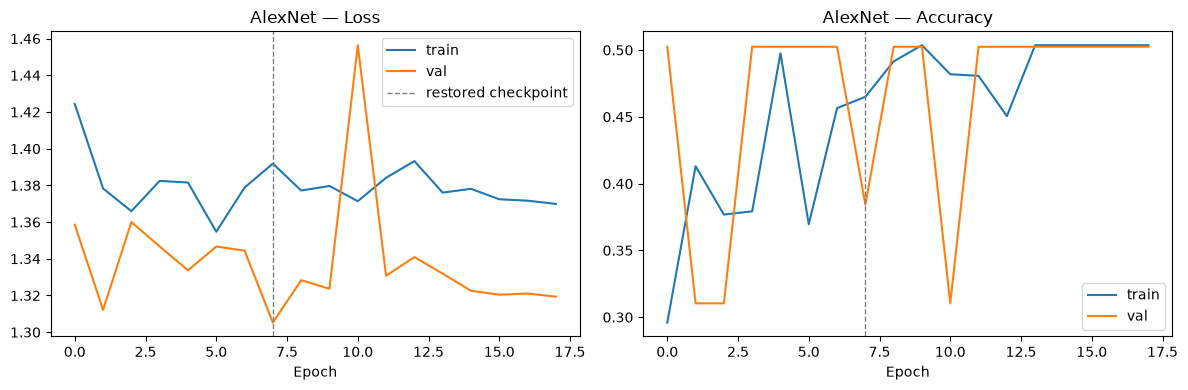

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "AlexNet", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "AlexNet")

## Evaluate on the test set

[AlexNet] Test accuracy: 0.508


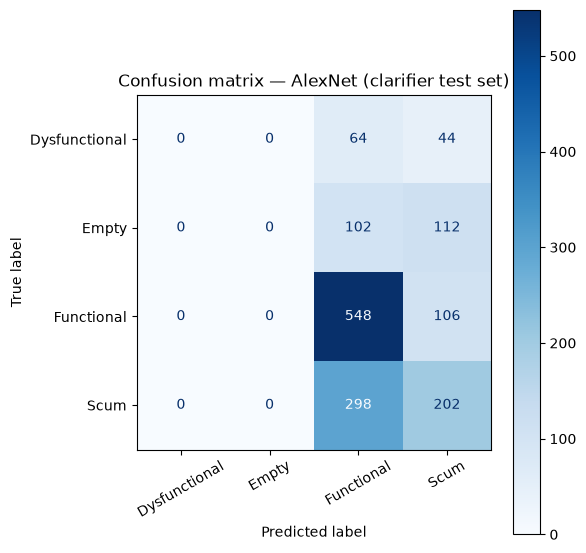

               precision    recall  f1-score   support

Dysfunctional      0.000     0.000     0.000       108
        Empty      0.000     0.000     0.000       214
   Functional      0.542     0.838     0.658       654
         Scum      0.435     0.404     0.419       500

     accuracy                          0.508      1476
    macro avg      0.244     0.310     0.269      1476
 weighted avg      0.387     0.508     0.433      1476



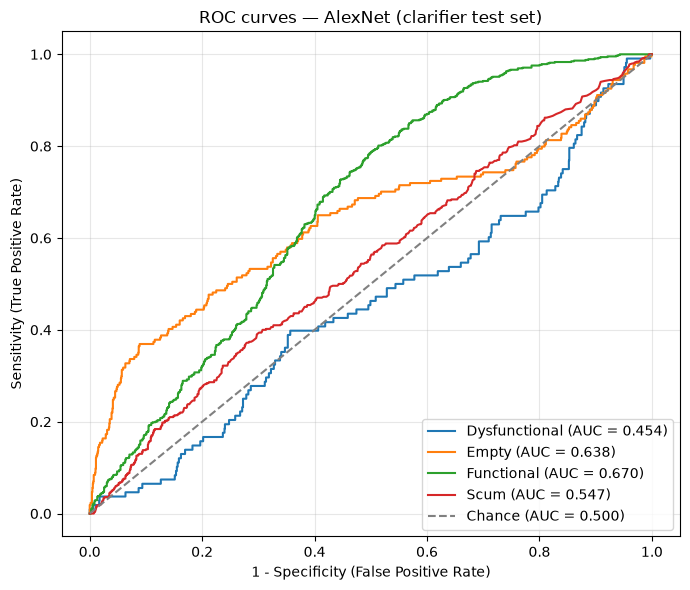

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.454
  Empty          : 0.638
  Functional     : 0.670
  Scum           : 0.547

Mean AUC (over 4/4 classes with test examples): 0.577


(np.float64(0.508130081300813),
 {'Dysfunctional': 0.4539575211176088,
  'Empty': 0.6377967771079875,
  'Functional': 0.6700409979389421,
  'Scum': 0.5471659836065573})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "AlexNet", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("AlexNet", "alexnet")

Saved results to ../results/results_clarifier_alexnet_CapeFlats.pkl


Saved model weights to ../models/clarifier_alexnet_cnn.pt
